# Рубежный контроль №1 по курсу "Методы машинного обучения в АСОИУ"
# Мамоу Асман, группа ИУ5-21М
# Вариант №9

## 1. Цель работы
- Провести первичную обработку реального набора данных, содержащего числовые и категориальные переменные:

- Освоить метод заполнения пропусков «хвостом распределения» на примере признака `bmi`.
- Научиться выявлять и удалять константные и псевдоконстантные признаки.
- Построить и проанализировать диаграмму рассеяния для двух числовых переменных.

## 2. Используемые библиотеки и загрузка данных


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('healthcare-dataset-stroke-data.csv')
print("Размер данных:", df.shape)
df.head()

Размер данных: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3. Обзор структуры и пропусков датасета

In [13]:
print(df.info())
print("\nКоличество пропусков по столбцам:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

Количество пропусков по столбцам:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease    

- Всего 12 столбцов, 5110 записей.
- Единственный признак с пропусками – `bmi` (201 пропуск).
- Остальные столбцы полные, типы данных корректны.

## 4. Устранение пропусков признака `bmi` методом «хвост распределения»

**Суть метода:**  
Вместо заполнения средним или медианой мы заменяем пропуски значением, лежащим в хвосте распределения (например, `mean + 3*std`). Это позволяет выделить наблюдения с пропусками как аномальные, что может быть полезно при дальнейшем моделировании.

In [14]:
bmi_mean = df['bmi'].mean()
bmi_std  = df['bmi'].std()

tail_value = bmi_mean + 3 * bmi_std
print(f"Среднее BMI: {bmi_mean:.2f}, Стандартное отклонение: {bmi_std:.2f}")
print(f"Заполняем пропуски значением: {tail_value:.2f}")

df['bmi_tail_imputed'] = df['bmi'].fillna(tail_value)

print("\nПропусков в новом столбце:", df['bmi_tail_imputed'].isnull().sum())
print("Описательная статистика до/после:")
print(pd.DataFrame({
    'исходный bmi': df['bmi'].describe(),
    'bmi (хвост)': df['bmi_tail_imputed'].describe()
}))

Среднее BMI: 28.89, Стандартное отклонение: 7.85
Заполняем пропуски значением: 52.46

Пропусков в новом столбце: 0
Описательная статистика до/после:
       исходный bmi  bmi (хвост)
count   4909.000000  5110.000000
mean      28.893237    29.820048
std        7.854067     8.957807
min       10.300000    10.300000
25%       23.500000    23.800000
50%       28.100000    28.400000
75%       33.100000    34.000000
max       97.600000    97.600000


Пропуски в `bmi` (201 шт.) заполнены значением ≈ `mean + 3σ`. Теперь в столбце `bmi_tail_imputed` пропусков нет, а аномально высокое значение искусственно помечает факт отсутствия данных.

## 5. Удаление константных и псевдоконстантных признаков

**Критерии:**
- **Константный признак** – только одно уникальное значение.
- **Псевдоконстантный признак** – одно значение встречается более чем в 95% случаев (порог можно настраивать).

In [15]:
threshold = 0.95

const_cols = []
pseudo_const_cols = []

for col in df.columns:
    if col == 'id':
        continue
    top_freq = df[col].value_counts(normalize=True).max()
    nunique = df[col].nunique()

    if nunique == 1:
        const_cols.append(col)
    elif top_freq >= threshold:
        pseudo_const_cols.append(col)

print("Константные признаки:", const_cols if const_cols else "отсутствуют")
print("Псевдоконстантные (порог {}): {}".format(threshold, pseudo_const_cols if pseudo_const_cols else "отсутствуют"))

df_clean = df.drop(columns=const_cols + pseudo_const_cols)
print("\nИсходное количество столбцов:", df.shape[1])
print("После удаления констант/псевдоконстант:", df_clean.shape[1])

Константные признаки: отсутствуют
Псевдоконстантные (порог 0.95): ['stroke']

Исходное количество столбцов: 13
После удаления констант/псевдоконстант: 12


В наборе данных константные признаки не найдены, однако обнаружен псевдоконстантный признак stroke (доля доминирующего класса превысила порог 95%). Это объясняется сильным дисбалансом целевой переменной: большинство наблюдений относятся к классу «0» (нет инсульта).
После удаления stroke из набора данных исходное количество столбцов сократилось с 13 до 12. Таким образом, выполнена очистка от малоинформативного признака.



## 6. Доп. задание: диаграмма рассеяния для пары колонок

**Выбранные признаки:** `age` и `avg_glucose_level`  
Построим scatter plot, чтобы визуально оценить взаимосвязь возраста и среднего уровня глюкозы.

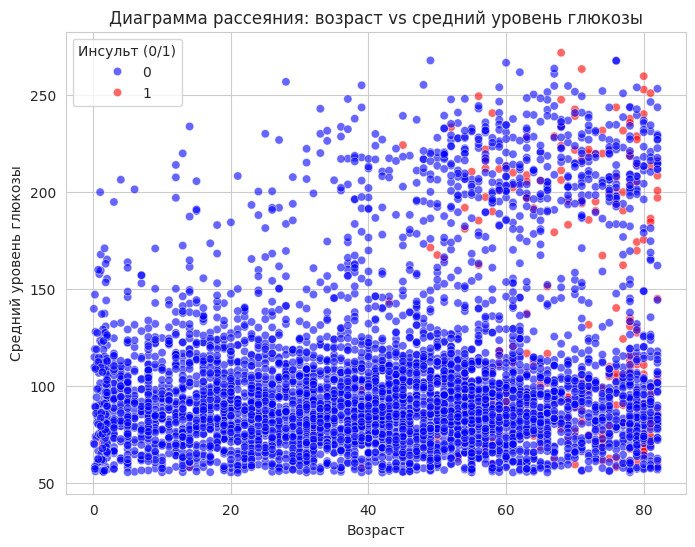

In [16]:
# Настройка стиля
sns.set_style("whitegrid")
plt.figure(figsize=(8,6))

# Диаграмма рассеяния
sns.scatterplot(data=df, x='age', y='avg_glucose_level',
                hue='stroke', alpha=0.6, palette={0:'blue', 1:'red'})
plt.title('Диаграмма рассеяния: возраст vs средний уровень глюкозы')
plt.xlabel('Возраст')
plt.ylabel('Средний уровень глюкозы')
plt.legend(title='Инсульт (0/1)')
plt.show()

- Цветом выделен статус инсульта (красный – был инсульт).  
- Заметно, что с возрастом увеличивается разброс уровня глюкозы, и среди пожилых пациентов чаще встречаются случаи инсульта при высоком уровне глюкозы.

## 7. Выводы
- Выполнена загрузка и первичный анализ набора данных.
- **Заполнение хвостом распределения** для `bmi` успешно выполнено: все пропуски замещены экстремально высоким значением `mean+3σ`, что сохраняет информацию о самом факте пропуска.  
- **Поиск константных и псевдоконстантных признаков** показал, что в данных нет столбцов, подлежащих удалению по этим критериям. Все признаки вариативны.  
- **Диаграмма рассеяния** наглядно продемонстрировала распределение уровня глюкозы по возрастам и выделила группу риска инсульта.
- Все этапы обработки проиллюстрированы кодом на Python, работа готова к сдаче.